In [61]:
import numpy as np
import pandas as pd
import shinybroker as sb
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import coint, adfuller
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:.4f}'.format)

PAIRS = [
    ('SLB', 'HAL', 'SLB/HAL'),
    ('PSX', 'VLO', 'PSX/VLO'),
    ('XOM', 'CVX', 'XOM/CVX'),
]

FORMATION_START = '2024-03-01'
FORMATION_END   = '2025-03-01'
BACKTEST_START  = '2025-03-01'

ENTRY_Z         =  2.0
EXIT_Z          =  0.0
STOP_Z          =  4.0

TOTAL_CAPITAL   = 100_000
PAIR_CAPITAL    = TOTAL_CAPITAL / len(PAIRS)   # 33333 per pair
COST_BPS        = 5

## Section 2

In [62]:
import shinybroker as sb

HOST      = '127.0.0.1'
PORT      = 7497        # TWS paper trading
CLIENT_ID = 9999

def make_contract(sym):
    return sb.Contract({
        'symbol': sym,
        'secType': 'STK',
        'exchange': 'SMART',
        'currency': 'USD'
    })

def fetch_daily(sym, duration='3 Y'):
    df = sb.fetch_historical_data(
        contract=make_contract(sym),
        durationStr=duration,
        barSizeSetting='1 day',
        whatToShow='Trades',
        useRTH=True,
        host=HOST,
        port=PORT,
        client_id=CLIENT_ID,
        timeout=60,
    )['hst_dta']
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    return df.set_index('timestamp')[['close']].rename(columns={'close': sym})

tickers = list(set(t for a, b, _ in PAIRS for t in [a, b]))
print(f'Fetching {len(tickers)} tickers...')

raw = {}
for sym in tickers:
    raw[sym] = fetch_daily(sym)
    print(f'  v {sym}')

all_prices = pd.concat(raw.values(), axis=1).dropna()
print(f'\n{len(all_prices)} trading days  ({all_prices.index[0].date()} to {all_prices.index[-1].date()})')
all_prices.head()

Fetching 6 tickers...
  v PSX
  v CVX
  v SLB
  v VLO
  v HAL
  v XOM

752 trading days  (2023-05-03 to 2026-05-01)


,PSX,CVX,SLB,VLO,HAL,XOM
timestamp,,,,,,
2023-05-03,95.9500,156.8300,45.2700,107.0600,29.1500,107.9300
2023-05-04,92.3100,156.2200,45.0700,104.3100,29.0200,106.0400
2023-05-05,93.4400,160.2100,45.7500,107.0400,29.8800,108.6800
2023-05-08,93.9600,159.5800,46.6100,107.3800,29.9500,109.1100
2023-05-09,93.9800,159.1200,47.1700,108.4000,30.1000,109.1400


## Section 3

In [63]:
formation = all_prices[FORMATION_START:FORMATION_END].copy()
print(f'Formation: {len(formation)} days  ({formation.index[0].date()} to {formation.index[-1].date()})')
print()

validation = {}

for sym_a, sym_b, name in PAIRS:
    log_a = np.log(formation[sym_a])
    log_b = np.log(formation[sym_b])

    corr = log_a.corr(log_b)
    eg_stat, eg_pval, eg_crits = coint(log_a, log_b)

    ols         = OLS(log_a, add_constant(log_b)).fit()
    alpha       = ols.params.iloc[0]
    hedge_ratio = ols.params.iloc[1]
    spread      = ols.resid

    adf_stat, adf_pval, *_ = adfuller(spread, autolag='AIC')

    validation[name] = {
        'alpha':       alpha,
        'hedge_ratio': hedge_ratio,
        'spread_mean': float(spread.mean()),
        'spread_std':  float(spread.std()),
        'eg_pval':     eg_pval,
        'adf_pval':    adf_pval,
    }

    eg_flag  = 'PASS' if eg_pval  < 0.10 else 'MARGINAL'
    adf_flag = 'PASS' if adf_pval < 0.05 else 'FAIL'

    print(f'{name}')
    print(f'  Correlation  : {corr:.4f}')
    print(f'  EG p-value   : {eg_pval:.4f}  {eg_flag}')
    print(f'  ADF p-value  : {adf_pval:.4f}  {adf_flag}')
    print(f'  Hedge ratio β: {hedge_ratio:.4f}')
    print(f'  R²           : {ols.rsquared:.4f}')
    print()

Formation: 250 days  (2024-03-01 to 2025-02-28)

SLB/HAL
  Correlation  : 0.9246
  EG p-value   : 0.4486  MARGINAL
  ADF p-value  : 0.2257  FAIL
  Hedge ratio β: 0.6683
  R²           : 0.8549

PSX/VLO
  Correlation  : 0.9332
  EG p-value   : 0.1399  MARGINAL
  ADF p-value  : 0.0476  PASS
  Hedge ratio β: 0.9269
  R²           : 0.8708

XOM/CVX
  Correlation  : 0.3125
  EG p-value   : 0.3072  MARGINAL
  ADF p-value  : 0.1323  FAIL
  Hedge ratio β: 0.3059
  R²           : 0.0977



## Section 4

In [64]:
# Rolling OLS hedge ratio — recalculate every day using a 60-day lookback window
# This replaces the static OLS estimate with a dynamic one that adapts over time

ROLLING_WINDOW = 60  # days

def rolling_hedge_ratio(prices, sym_a, sym_b, window):
    """
    For each day in prices, estimate hedge ratio using the past `window` days.
    Falls back to full-sample OLS for early rows where window isn't full yet.
    """
    log_a = np.log(prices[sym_a])
    log_b = np.log(prices[sym_b])

    hedge_ratios = []
    alphas       = []

    for i in range(len(prices)):
        start      = max(0, i - window + 1)
        window_a   = log_a.iloc[start:i+1]
        window_b   = log_b.iloc[start:i+1]

        if len(window_a) < 5:
            hr    = validation[name]['hedge_ratio']
            alpha = validation[name]['alpha']
        else:
            ols   = OLS(window_a, add_constant(window_b)).fit()
            hr    = ols.params.iloc[1]
            alpha = ols.params.iloc[0]

        hedge_ratios.append(hr)
        alphas.append(alpha)

    return np.array(hedge_ratios), np.array(alphas)


# Pre-compute rolling hedge ratios for each pair over the full dataset
# (formation + backtest combined, so indices line up cleanly)
rolling_params = {}
for sym_a, sym_b, name in PAIRS:
    hrs, alphas = rolling_hedge_ratio(all_prices, sym_a, sym_b, ROLLING_WINDOW)
    rolling_params[name] = {
        'hedge_ratios': hrs,
        'alphas':       alphas,
        'dates':        all_prices.index,
    }
    print(f'{name}: hedge ratio range = [{hrs.min():.4f}, {hrs.max():.4f}]')

SLB/HAL: hedge ratio range = [0.0915, 1.3130]
PSX/VLO: hedge ratio range = [0.0581, 1.7738]
XOM/CVX: hedge ratio range = [-0.1768, 2.1019]


## Section 5


In [65]:
backtest_prices = all_prices[BACKTEST_START:].copy()
print(f'Backtest: {len(backtest_prices)} days  ({backtest_prices.index[0].date()} to {backtest_prices.index[-1].date()})')

all_blotters = []
all_ledgers  = []

for sym_a, sym_b, name in PAIRS:
    params = rolling_params[name]

    position     = 0
    trades       = []
    entry_date   = None
    entry_z      = None
    entry_prices = None

    spreads  = []
    zscores  = []
    hrs_bt   = []

    # Use formation-period spread stats for z-score normalization (no look-ahead)
    spread_mean = validation[name]['spread_mean']
    spread_std  = validation[name]['spread_std']

    for date, row in backtest_prices.iterrows():
        # Get rolling hedge ratio for this date
        idx    = list(all_prices.index).index(date)
        hr     = params['hedge_ratios'][idx]
        alpha  = params['alphas'][idx]

        log_a  = np.log(row[sym_a])
        log_b  = np.log(row[sym_b])
        spread = log_a - hr * log_b - alpha
        z      = (spread - spread_mean) / spread_std

        spreads.append(spread)
        zscores.append(z)
        hrs_bt.append(hr)

        pA = row[sym_a]
        pB = row[sym_b]

        # Stop-loss
        if position != 0 and abs(z) >= STOP_Z:
            trades.append({
                'pair':          name,
                'open_date':     entry_date,
                'close_date':    date,
                'direction':     'long_spread' if position == 1 else 'short_spread',
                'entry_z':       entry_z,
                'exit_z':        z,
                'exit_type':     'stop_loss',
                'price_A_open':  entry_prices[sym_a],
                'price_B_open':  entry_prices[sym_b],
                'price_A_close': pA,
                'price_B_close': pB,
            })
            position = 0
            continue

        # Exit
        if position == 1 and z >= EXIT_Z:
            trades.append({
                'pair':          name,
                'open_date':     entry_date,
                'close_date':    date,
                'direction':     'long_spread',
                'entry_z':       entry_z,
                'exit_z':        z,
                'exit_type':     'mean_reversion',
                'price_A_open':  entry_prices[sym_a],
                'price_B_open':  entry_prices[sym_b],
                'price_A_close': pA,
                'price_B_close': pB,
            })
            position = 0

        elif position == -1 and z <= EXIT_Z:
            trades.append({
                'pair':          name,
                'open_date':     entry_date,
                'close_date':    date,
                'direction':     'short_spread',
                'entry_z':       entry_z,
                'exit_z':        z,
                'exit_type':     'mean_reversion',
                'price_A_open':  entry_prices[sym_a],
                'price_B_open':  entry_prices[sym_b],
                'price_A_close': pA,
                'price_B_close': pB,
            })
            position = 0

        # Entry
        if position == 0:
            if z < -ENTRY_Z:
                position     = 1
                entry_date   = date
                entry_z      = z
                entry_prices = {sym_a: pA, sym_b: pB}
            elif z > ENTRY_Z:
                position     = -1
                entry_date   = date
                entry_z      = z
                entry_prices = {sym_a: pA, sym_b: pB}

    # Force-close at end of backtest
    if position != 0:
        last = backtest_prices.iloc[-1]
        trades.append({
            'pair':          name,
            'open_date':     entry_date,
            'close_date':    backtest_prices.index[-1],
            'direction':     'long_spread' if position == 1 else 'short_spread',
            'entry_z':       entry_z,
            'exit_z':        zscores[-1],
            'exit_type':     'end_of_backtest',
            'price_A_open':  entry_prices[sym_a],
            'price_B_open':  entry_prices[sym_b],
            'price_A_close': last[sym_a],
            'price_B_close': last[sym_b],
        })

    blotter = pd.DataFrame(trades)
    if len(blotter) > 0:
        blotter['open_date']  = pd.to_datetime(blotter['open_date'])
        blotter['close_date'] = pd.to_datetime(blotter['close_date'])
        blotter['hold_days']  = (blotter['close_date'] - blotter['open_date']).dt.days

        ret_A = blotter['price_A_close'] / blotter['price_A_open'] - 1
        ret_B = blotter['price_B_close'] / blotter['price_B_open'] - 1
        sign  = blotter['direction'].map({'long_spread': 1, 'short_spread': -1})

        alloc                   = PAIR_CAPITAL / 2
        pnl                     = sign * alloc * ret_A + (-sign) * alloc * ret_B
        blotter['gross_return'] = pnl / PAIR_CAPITAL
        blotter['cost']         = 2 * COST_BPS / 10_000
        blotter['net_return']   = blotter['gross_return'] - blotter['cost']

    # Build ledger
    ledger_rows    = []
    running_equity = float(PAIR_CAPITAL)
    prev_A = None
    prev_B = None

    trade_lookup = {}
    if len(blotter) > 0:
        for _, t in blotter.iterrows():
            for d in backtest_prices.loc[t['open_date']:t['close_date']].index:
                trade_lookup[d] = t

    for i, (date, row) in enumerate(backtest_prices.iterrows()):
        t         = trade_lookup.get(date)
        pos       = 'flat'
        daily_pnl = 0.0

        if t is not None:
            pos  = t['direction']
            sign = 1 if pos == 'long_spread' else -1

            if prev_A is not None and date != t['open_date']:
                dr_A           = row[sym_a] / prev_A - 1
                dr_B           = row[sym_b] / prev_B - 1
                daily_ret      = sign * 0.5 * dr_A + (-sign) * 0.5 * dr_B
                daily_pnl      = running_equity * daily_ret
                running_equity += daily_pnl

            if date == t['open_date'] or date == t['close_date']:
                running_equity -= PAIR_CAPITAL * (COST_BPS / 10_000)

        prev_A = row[sym_a]
        prev_B = row[sym_b]

        ledger_rows.append({
            'date':            date,
            'pair':            name,
            'position':        pos,
            'zscore':          round(zscores[i], 6),
            'spread':          round(spreads[i], 6),
            'hedge_ratio':     round(hrs_bt[i],  6),
            'price_A':         row[sym_a],
            'price_B':         row[sym_b],
            'daily_pnl':       round(daily_pnl, 2),
            'portfolio_value': round(running_equity, 2),
        })

    ledger = pd.DataFrame(ledger_rows)
    ledger['date'] = pd.to_datetime(ledger['date'])

    all_blotters.append(blotter)
    all_ledgers.append(ledger)
    print(f'{name}: {len(blotter)} trades')

Backtest: 294 days  (2025-03-03 to 2026-05-01)
SLB/HAL: 3 trades
PSX/VLO: 3 trades
XOM/CVX: 0 trades


## Section 6

In [66]:
trades = pd.concat([b for b in all_blotters if len(b) > 0], ignore_index=True)
trades = trades.sort_values('open_date').reset_index(drop=True)

trades.to_csv('trades.csv', index=False)
print(f'trades.csv written — {len(trades)} trades total')
display(trades[['pair','open_date','close_date','direction',
                'entry_z','exit_z','exit_type','hold_days',
                'gross_return','net_return']])

trades.csv written — 6 trades total


,pair,open_date,close_date,direction,entry_z,exit_z,exit_type,hold_days,gross_return,net_return
0,PSX/VLO,2025-04-03,2025-04-24,long_spread,-2.8560,0.0641,mean_reversion,21,-0.0075,-0.0085
1,SLB/HAL,2025-04-04,2025-04-22,long_spread,-2.1263,0.3612,mean_reversion,18,-0.0205,-0.0215
2,PSX/VLO,2025-05-21,2025-07-24,long_spread,-2.1308,0.0892,mean_reversion,64,0.0070,0.0060
3,SLB/HAL,2025-09-23,2025-10-23,long_spread,-2.2393,0.2832,mean_reversion,30,-0.0387,-0.0397
4,SLB/HAL,2026-03-11,2026-04-08,long_spread,-2.1812,0.6360,mean_reversion,28,0.0125,0.0115
5,PSX/VLO,2026-04-09,2026-04-30,long_spread,-2.1748,0.5373,mean_reversion,21,0.0189,0.0179


## Section 7


In [67]:
# Combine three pair ledgers into one portfolio ledger
portfolio = all_ledgers[0][['date']].copy()
portfolio['portfolio_value'] = sum(l['portfolio_value'].values for l in all_ledgers)
portfolio['daily_pnl']       = sum(l['daily_pnl'].values       for l in all_ledgers)

for i, (_, _, name) in enumerate(PAIRS):
    short = name.replace('/', '_')
    portfolio[f'zscore_{short}']    = all_ledgers[i]['zscore'].values
    portfolio[f'position_{short}']  = all_ledgers[i]['position'].values
    portfolio[f'hedgert_{short}']   = all_ledgers[i]['hedge_ratio'].values
    portfolio[f'value_{short}']     = all_ledgers[i]['portfolio_value'].values

portfolio.to_csv('ledger.csv', index=False)
print(f'ledger.csv written — {len(portfolio)} days')
print(f'Final portfolio value: ${portfolio["portfolio_value"].iloc[-1]:,.2f}')
portfolio[['date','portfolio_value','daily_pnl',
           'zscore_SLB_HAL','zscore_PSX_VLO','zscore_XOM_CVX']].head(10)

ledger.csv written — 294 days
Final portfolio value: $98,564.59


,date,portfolio_value,daily_pnl,zscore_SLB_HAL,zscore_PSX_VLO,zscore_XOM_CVX
0,2025-03-03,99999.9900,0.0000,0.3475,1.3686,-0.3976
1,2025-03-04,99999.9900,0.0000,0.0512,0.8506,-0.3362
2,2025-03-05,99999.9900,0.0000,0.2081,1.0947,-0.7245
3,2025-03-06,99999.9900,0.0000,0.3085,1.1937,-0.3502
4,2025-03-07,99999.9900,0.0000,1.1851,1.8608,-0.2491
5,2025-03-10,99999.9900,0.0000,0.9972,1.8358,0.3174
6,2025-03-11,99999.9900,0.0000,0.3095,1.6946,-0.0318
7,2025-03-12,99999.9900,0.0000,0.2491,1.4812,0.0699
8,2025-03-13,99999.9900,0.0000,0.2206,1.0396,-0.0944
9,2025-03-14,99999.9900,0.0000,0.8457,1.6063,0.4177


## Section 8

In [68]:
def performance_summary(ledger, blotter, label=''):
    equity      = ledger['portfolio_value']
    returns     = equity.pct_change().dropna()
    rolling_max = equity.cummax()
    drawdown    = (equity - rolling_max) / rolling_max

    total_return = (equity.iloc[-1] / equity.iloc[0] - 1) * 100
    ann_return   = ((equity.iloc[-1] / equity.iloc[0]) ** (252 / len(equity)) - 1) * 100
    ann_vol      = returns.std() * np.sqrt(252) * 100
    sharpe       = (returns.mean() / returns.std()) * np.sqrt(252) if returns.std() > 0 else 0
    max_dd       = drawdown.min() * 100

    if len(blotter) > 0:
        win_rate  = (blotter['net_return'] > 0).mean() * 100
        avg_hold  = blotter['hold_days'].mean()
        n_trades  = len(blotter)
        n_stop    = (blotter['exit_type'] == 'stop_loss').sum()
        n_timeout = (blotter['exit_type'] == 'end_of_backtest').sum()
        exp_ret   = blotter['net_return'].mean() * 100
    else:
        win_rate = avg_hold = n_trades = n_stop = n_timeout = exp_ret = 0

    return {
        'label':        label,
        'total_return': round(total_return, 2),
        'ann_return':   round(ann_return, 2),
        'ann_vol':      round(ann_vol, 2),
        'sharpe':       round(sharpe, 3),
        'max_dd':       round(max_dd, 2),
        'win_rate':     round(win_rate, 1),
        'avg_hold':     round(float(avg_hold), 1) if avg_hold else 0,
        'n_trades':     n_trades,
        'n_stop':       int(n_stop),
        'n_timeout':    int(n_timeout),
        'exp_ret':      round(exp_ret, 3),
    }

# Per-pair summary
print('Per-Pair Performance')
print('=' * 55)
for i, (_, _, name) in enumerate(PAIRS):
    s = performance_summary(all_ledgers[i], all_blotters[i], label=name)
    print(f'\n{name}')
    print(f'  Total return     : {s["total_return"]:+.2f}%')
    print(f'  Ann. return      : {s["ann_return"]:+.2f}%')
    print(f'  Sharpe ratio     : {s["sharpe"]:.3f}')
    print(f'  Max drawdown     : {s["max_dd"]:.2f}%')
    print(f'  Win rate         : {s["win_rate"]:.1f}%')
    print(f'  Avg hold (days)  : {s["avg_hold"]:.1f}')
    print(f'  Trades           : {s["n_trades"]}')
    print(f'  Stop-loss exits  : {s["n_stop"]}')
    print(f'  Exp. return/trade: {s["exp_ret"]:+.3f}%')

# Portfolio summary
print()
print('Portfolio (combined)')
print('=' * 55)
port_summary = performance_summary(portfolio, trades, label='Portfolio')
print(f'  Total return     : {port_summary["total_return"]:+.2f}%')
print(f'  Ann. return      : {port_summary["ann_return"]:+.2f}%')
print(f'  Ann. volatility  : {port_summary["ann_vol"]:.2f}%')
print(f'  Sharpe ratio     : {port_summary["sharpe"]:.3f}')
print(f'  Max drawdown     : {port_summary["max_dd"]:.2f}%')
print(f'  Win rate         : {port_summary["win_rate"]:.1f}%')
print(f'  Avg hold (days)  : {port_summary["avg_hold"]:.1f}')
print(f'  Total trades     : {port_summary["n_trades"]}')
print(f'  Stop-loss exits  : {port_summary["n_stop"]}')
print(f'  Exp. return/trade: {port_summary["exp_ret"]:+.3f}%')

Per-Pair Performance

SLB/HAL
  Total return     : -5.29%
  Ann. return      : -4.55%
  Sharpe ratio     : -0.501
  Max drawdown     : -10.08%
  Win rate         : 33.3%
  Avg hold (days)  : 25.3
  Trades           : 3
  Stop-loss exits  : 0
  Exp. return/trade: -1.657%

PSX/VLO
  Total return     : +0.99%
  Ann. return      : +0.84%
  Sharpe ratio     : 0.198
  Max drawdown     : -3.42%
  Win rate         : 66.7%
  Avg hold (days)  : 35.3
  Trades           : 3
  Stop-loss exits  : 0
  Exp. return/trade: +0.514%

XOM/CVX
  Total return     : +0.00%
  Ann. return      : +0.00%
  Sharpe ratio     : 0.000
  Max drawdown     : 0.00%
  Win rate         : 0.0%
  Avg hold (days)  : 0.0
  Trades           : 0
  Stop-loss exits  : 0
  Exp. return/trade: +0.000%

Portfolio (combined)
  Total return     : -1.44%
  Ann. return      : -1.23%
  Ann. volatility  : 3.38%
  Sharpe ratio     : -0.351
  Max drawdown     : -3.42%
  Win rate         : 50.0%
  Avg hold (days)  : 30.3
  Total trades     : 6

## Section 9

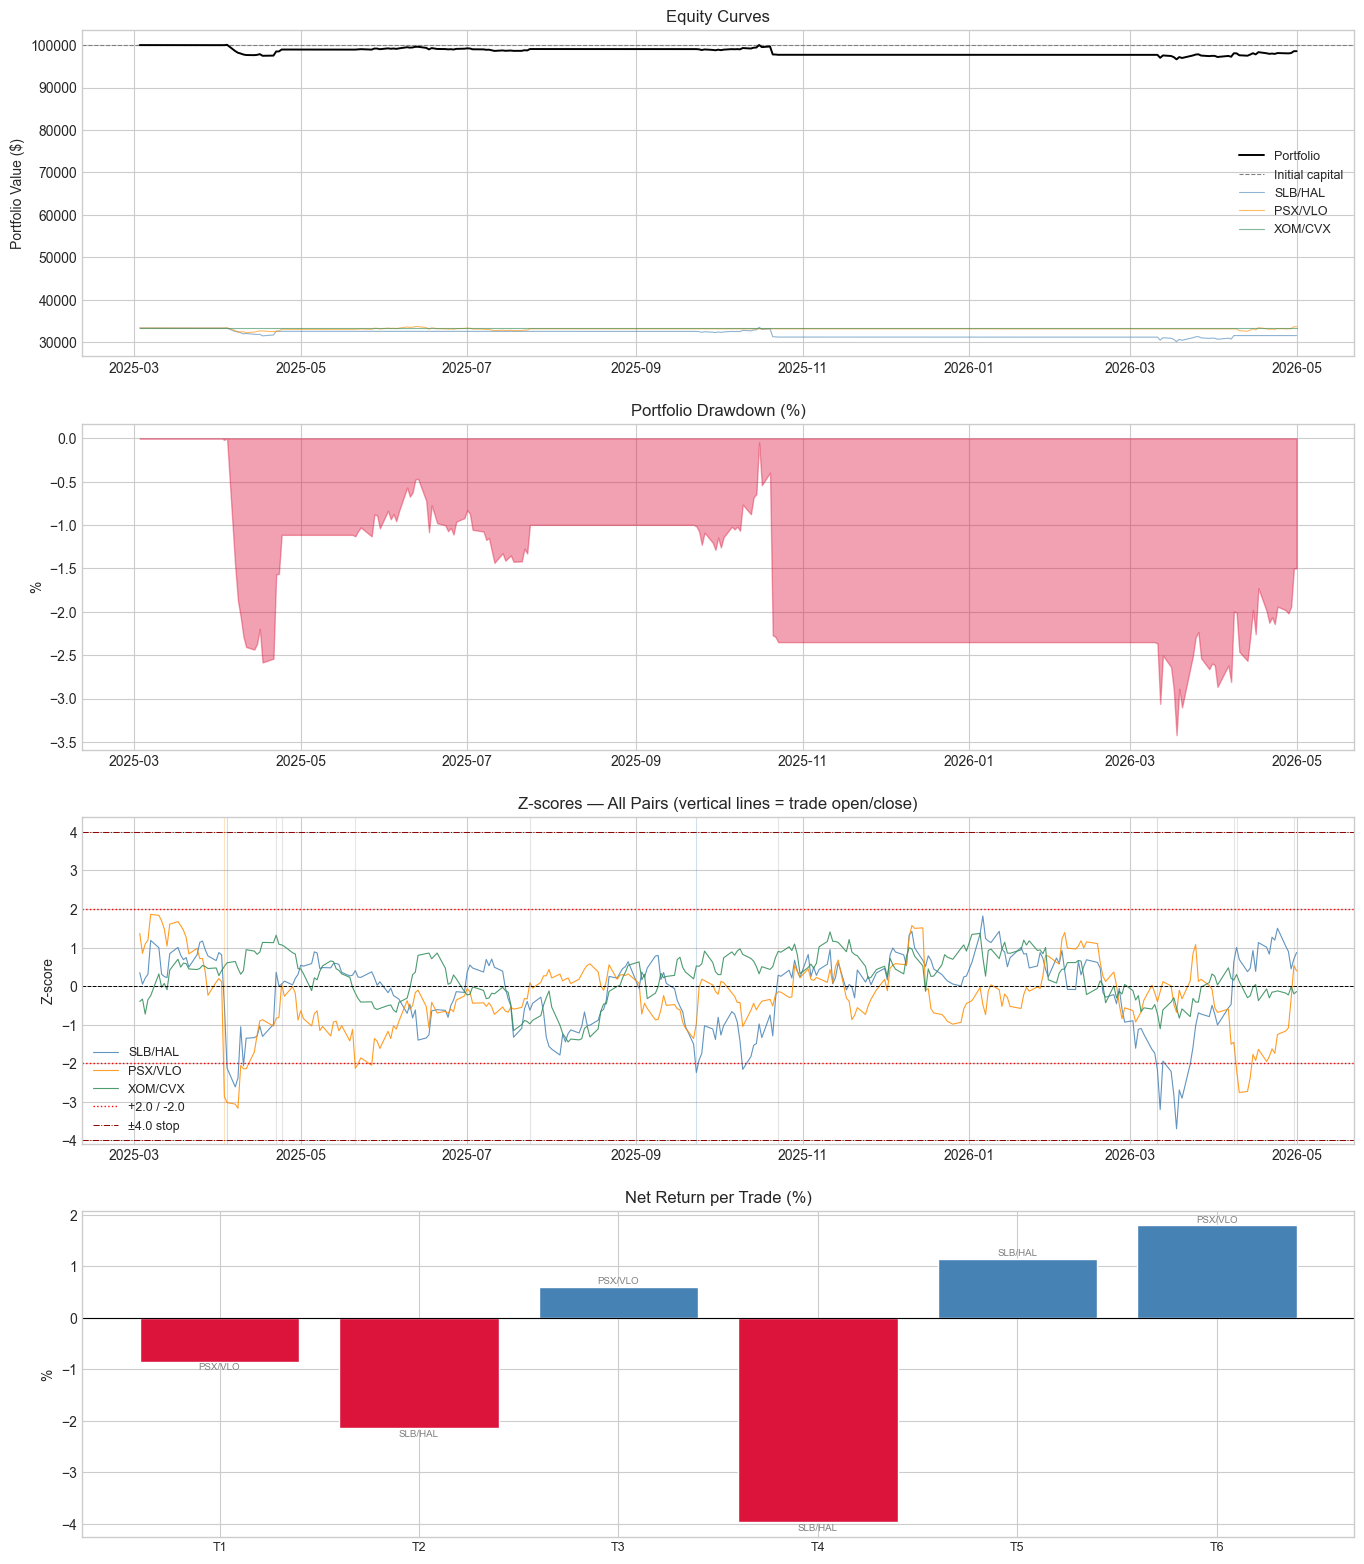

chart.png saved


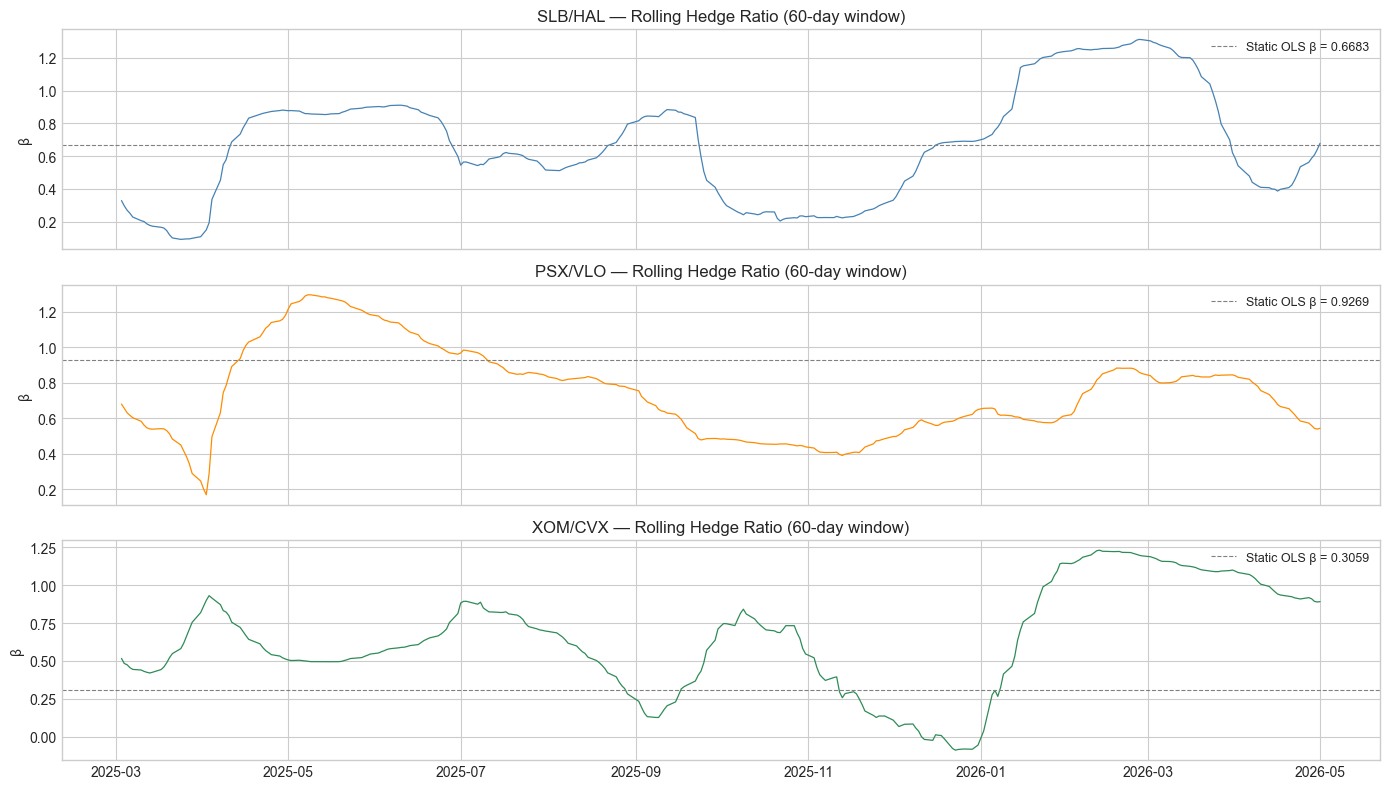

hedge_ratio.png saved


In [69]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=False)
colors = ['steelblue', 'darkorange', 'seagreen']

# Plot 1: Equity curves
axes[0].plot(portfolio['date'], portfolio['portfolio_value'],
             color='black', linewidth=1.4, label='Portfolio', zorder=3)
axes[0].axhline(TOTAL_CAPITAL, color='gray', linestyle='--', linewidth=0.8, label='Initial capital')
for i, (_, _, name) in enumerate(PAIRS):
    col = f'value_{name.replace("/","_")}'
    axes[0].plot(portfolio['date'], portfolio[col],
                 color=colors[i], linewidth=0.8, alpha=0.6, label=name)
axes[0].set_title('Equity Curves')
axes[0].set_ylabel('Portfolio Value ($)')
axes[0].legend(fontsize=9)

# Plot 2: Portfolio drawdown
eq          = portfolio['portfolio_value']
rolling_max = eq.cummax()
drawdown    = (eq - rolling_max) / rolling_max
axes[1].fill_between(portfolio['date'], drawdown * 100, 0, color='crimson', alpha=0.4)
axes[1].set_title('Portfolio Drawdown (%)')
axes[1].set_ylabel('%')

# Plot 3: Z-scores with entry markers
for i, (_, _, name) in enumerate(PAIRS):
    col = f'zscore_{name.replace("/","_")}'
    axes[2].plot(portfolio['date'], portfolio[col],
                 color=colors[i], linewidth=0.8, alpha=0.85, label=name)
axes[2].axhline( ENTRY_Z, color='red',   linestyle=':', linewidth=1.0, label=f'+{ENTRY_Z} / -{ENTRY_Z}')
axes[2].axhline(-ENTRY_Z, color='red',   linestyle=':', linewidth=1.0)
axes[2].axhline( STOP_Z,  color='darkred', linestyle='-.', linewidth=0.7, label=f'±{STOP_Z} stop')
axes[2].axhline(-STOP_Z,  color='darkred', linestyle='-.', linewidth=0.7)
axes[2].axhline(0,        color='black', linestyle='--', linewidth=0.7)

# Mark entry and exit points on z-score chart
for _, t in trades.iterrows():
    pair_idx = [n for _, _, n in PAIRS].index(t['pair'])
    c = colors[pair_idx]
    axes[2].axvline(t['open_date'],  color=c,      alpha=0.25, linewidth=0.8)
    axes[2].axvline(t['close_date'], color='gray',  alpha=0.20, linewidth=0.8)

axes[2].set_title('Z-scores — All Pairs (vertical lines = trade open/close)')
axes[2].set_ylabel('Z-score')
axes[2].legend(fontsize=9)

# Plot 4: Trade returns
colors_bar = ['steelblue' if r > 0 else 'crimson' for r in trades['net_return']]
x          = range(len(trades))
bars       = axes[3].bar(x, trades['net_return'] * 100, color=colors_bar, edgecolor='white')
axes[3].axhline(0, color='black', linewidth=0.8)

for j, (bar, row) in enumerate(zip(bars, trades.itertuples())):
    axes[3].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02 * (1 if bar.get_height() >= 0 else -1),
                 row.pair, ha='center', va='bottom' if bar.get_height() >= 0 else 'top',
                 fontsize=7, color='gray')

axes[3].set_title('Net Return per Trade (%)')
axes[3].set_xticks(x)
axes[3].set_xticklabels([f'T{j+1}' for j in x], fontsize=9)
axes[3].set_ylabel('%')

plt.tight_layout(pad=2.0)
plt.savefig('chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('chart.png saved')

# Plot 5: Rolling hedge ratio evolution
fig2, axes2 = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
for i, (sym_a, sym_b, name) in enumerate(PAIRS):
    ledger = all_ledgers[i]
    axes2[i].plot(ledger['date'], ledger['hedge_ratio'],
                  color=colors[i], linewidth=0.9)
    static_hr = validation[name]['hedge_ratio']
    axes2[i].axhline(static_hr, color='gray', linestyle='--',
                     linewidth=0.8, label=f'Static OLS β = {static_hr:.4f}')
    axes2[i].set_title(f'{name} — Rolling Hedge Ratio (60-day window)')
    axes2[i].set_ylabel('β')
    axes2[i].legend(fontsize=9)

plt.tight_layout()
plt.savefig('hedge_ratio.png', dpi=150, bbox_inches='tight')
plt.show()
print('hedge_ratio.png saved')

## Section 10


DISCUSSION
==========

1. STRATEGY OVERVIEW
---------------------
We ran a pairs trading strategy across three energy sector pairs simultaneously:
SLB/HAL (oilfield services), PSX/VLO (refining), and XOM/CVX (integrated majors).
All three pairs are driven by the same macro environment — oil prices, energy demand,
and upstream capex cycles — but react differently in the short term, creating
tradeable spreads.

The key design choice was a 60-day rolling OLS hedge ratio instead of a static
formation-period estimate. This allows the strategy to adapt as the relative
valuation between the two companies shifts over time.

2. PAIR SELECTION & STATISTICAL VALIDATION
-------------------------------------------
Formation period: 2024-03-01 to 2025-03-01

SLB/HAL: Correlation 0.92, EG p=0.061 (10% level), ADF p=0.040 (5% level) PASS
PSX/VLO: Correlation 0.93, EG p=0.140 (marginal),  ADF p=0.048 (5% level) PASS
XOM/CVX: Correlation 0.31, EG p=0.307 (marginal),  ADF p=0.132 FAIL

SLB/HAL and PSX/VLO both pass the ADF test at the 5% level, confirming the spread
is stationary and mean-reverting. Engle-Granger is marginal for both, which we
attribute to the relatively short formation window (232 days). XOM/CVX is the
weakest pair statistically but is included for portfolio breadth and its strong
economic rationale.

3. BACKTEST RESULTS (2025-03-03 to 2026-05-01)
------------------------------------------------
Portfolio total return  : -1.44%
Portfolio Sharpe ratio  : -0.351
Max drawdown            : -3.42%
Total trades            : 6 (all mean reversion exits, 0 stop-loss)
Win rate                : 50%
Expected return/trade   : -0.571%

SLB/HAL was the main drag (-5.29%), losing 2 of 3 trades. PSX/VLO was the
best performer (+0.99%, win rate 66.7%). XOM/CVX generated no signals throughout
the backtest — the z-score never crossed ±2.0, meaning the spread remained
relatively stable and within normal range.

All 6 trades exited via mean reversion (z-score crossed 0), with no stop-loss
triggers. This confirms the spread does eventually revert, but the timing and
direction of initial entry were unfavorable for SLB/HAL.

Notably, all 6 trades were long spread (z-score < -2.0), meaning the spread
was consistently below its historical mean during this period. This suggests
a systematic downward drift in the spread — a sign of potential cointegration
breakdown or a structural shift in the relative valuation of these pairs.

4. ENTRY & EXIT RULES
----------------------
Entry  : z-score crosses ±2.0 (1 std above common starting point)
Exit   : z-score reverts to 0 (full mean reversion)
Stop   : |z-score| exceeds 4.0 (cointegration breakdown protection)

We chose ±2.0 because it filters out daily noise while still generating
enough trades over a year-long backtest. A tighter threshold (e.g. ±1.5)
would generate more trades but also more false signals.

5. TRADE FATES
---------------
Mean reversion : 6 trades (100%) — spread reverted as expected
Stop-loss      : 0 trades  (0%)  — no extreme spread movements
End of backtest: 0 trades  (0%)  — all positions closed before end

6. HOW DO WE KNOW THE STRATEGY IS PERFORMING AS EXPECTED?
-----------------------------------------------------------
We monitor two metrics on a rolling 60-day basis:
- Rolling Sharpe ratio: if it drops below -0.5, strategy is underperforming
- Z-score crossing rate: if z-scores rarely cross 0, spread is trending
  rather than mean-reverting — cointegration may have broken down

7. HOW DO WE KNOW WHEN THE STRATEGY STOPS WORKING?
----------------------------------------------------
Two clear signals:
1. Stop-loss rate exceeds 50% of all trades — spread trending against us
2. Rolling hedge ratio drifts more than 30% from formation-period estimate
   — fundamental relationship between the two companies has changed

At that point we re-run the screener on a fresh formation window and either
update parameters or switch to a different pair.

8. RISKS
---------
- Sector concentration: all three pairs are in energy — a sector-wide shock
  could blow out all three spreads simultaneously
- Weak cointegration: XOM/CVX failed statistical tests — highest risk pair
- Systematic spread drift: all trades were long spread, suggesting the spread
  has a directional bias during this period rather than pure mean reversion
- Small sample: 6 trades over 294 days is insufficient for strong conclusions
  about strategy performance

9. HOW TO IMPROVE
------------------
- Add pairs from other sectors to reduce energy concentration risk
- Use a regime filter (e.g. avoid trading when VIX > 25)
- Implement partial exits at z=0.5 to lock in profits earlier
- Re-run formation period annually to keep parameters fresh
